# India EV Infrastructure Analysis

**Author:** Shubham Banduni    

**Project Type:** Exploratory Data Analysis

---

### Business Problem
India's electric vehicle adoption is accelerating, but charging infrastructure deployment varies significantly across states and cities. This analysis identifies regional infrastructure gaps and underserved markets to support data-driven expansion strategies for EV charging networks.

### Objective
Analyze the distribution of EV charging stations across India relative to population and urbanization metrics to:
- Identify states and cities with inadequate charging infrastructure
- Calculate infrastructure readiness using per-capita metrics
- Recommend priority regions for network expansion
- Support strategic planning for EV ecosystem stakeholders

### Business Impact
- **For EV Companies:** Identify high-potential expansion markets
- **For Infrastructure Providers:** Prioritize investment locations
- **For Policymakers:** Understand infrastructure development needs
- **For Investors:** Assess market opportunities in underserved regions

### Datasets Used
1. **EV Charging Stations Dataset**
   - Source: Kaggle (based on public EV station registries)
   - Records: 1,547 charging stations across India
   - Features: Station name, location (state/city), coordinates, charger type
   - Year: 2024
   - [Download Dataset](https://www.kaggle.com/datasets/saketpradhan/electric-vehicle-charging-stations-in-india/data)

2. **Indian States Population & Demographics Dataset**
   - Source: Kaggle (census-based projections)
   - Records: 35 states and union territories
   - Features: Population (2024), area, literacy, GDP, demographics
   - Year: 2024
   - [Download Dataset](https://www.kaggle.com/datasets/samyakjain2052/indian-states-population-gdp-religion-sex-ratio)

### Section 1 : Data Loading & First Look

Importing Libraries

In [341]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


Loading Datasets

In [342]:
# EV Charging Stations Dataset
ev_df = pd.read_csv('../data/ev_charging_stations_india.csv')

# Population Dataset
pop_df = pd.read_csv('../data/statewise_pop.csv')

print("\nData loading complete")


Data loading complete


Data Overview

1. EV Charging Stations Dataset

In [343]:
# First 5 rows of EV Dataset
ev_df.head()

,name,state,city,address,lattitude,longitude,type
0,Neelkanth Star DC Charging Station,Haryana,Gurugram,"Neelkanth Star Karnal, NH 44, Gharunda, Kutail...",29.6019,76.9803,12.0
1,Galleria DC Charging Station,Haryana,Gurugram,"DLF Phase IV, Sector 28, Gurugram, Haryana 122022",28.4673,77.0818,12.0
2,Highway Xpress (Jaipur-Delhi) DC charging station,Rajasthan,Behror,"Jaipur to Delhi Road, Behror Midway, Behror, R...",27.8751,76.2760,12.0
3,Food Carnival DC Charging Station,Uttar Pradesh,Khatauli,"Fun and Food Carnival, NH 58, Khatauli Bypass,...",29.3105,77.7218,12.0
4,Food Carnival AC Charging Station,Uttar Pradesh,Khatauli,"NH 58, Khatauli Bypass, Bhainsi, Uttar Pradesh...",29.3105,77.7218,12.0


In [344]:
# Rows & Columns count
print(f"Number of Rows : {ev_df.shape[0]}")
print(f"Number of Columns : {ev_df.shape[1]}")

Number of Rows : 1547
Number of Columns : 7


In [345]:
# Column Names
print(f"List of column in dataset : {ev_df.columns.values}")

List of column in dataset : ['name' 'state' 'city' 'address' 'lattitude' 'longitude' 'type']


2. Indian States Population & Demographics Dataset

In [346]:
# First 5 rows of Population Dataset
pop_df.head()

,States/Uts,population(1901),population(1951),population(2011),population(2023),population(2024),Male(literacy rate),Female (literacy rate),average (literacy rate),Area (sq. km),GDP,per capita in,sex ratio (number of female per male),Hindu,Muslim,Christian,Sikhs,Buddhist,Others,Majority
0,Andaman and Nicobar Islands,24649,30971,380581,403000,404000,90.11,81.84,86.27,8249,0.89,229000.0,1045,0.6945,0.0852,0.2128,0.0034,0.0009,0.0032,Hindu
1,Andhra Pradesh,13071874,20216637,49386799,53217000,53402000,73.40,59.50,66.40,162970,14.50,219518.0,963,0.9087,0.0733,0.0138,0.0002,0.0001,0.0039,Hindu
2,Arunachal Pradesh,-,-,1383727,1565000,1580000,73.69,59.57,66.95,83743,0.38,256410.0,997,0.2904,0.0195,0.3026,0.0024,0.1177,0.2674,Christian
3,Assam,3289680,8028856,31205576,35824000,36159000,90.10,81.20,85.90,78438,5.67,118504.0,1012,0.6147,0.3422,0.0374,0.0007,0.0018,0.0032,Hindu
4,Bihar,27311865,29085017,104099452,127368000,129205000,79.70,60.50,70.90,94163,8.59,54000.0,1090,0.8269,0.1687,0.0012,0.0002,0.0002,0.0028,Hindu


In [347]:
# Rows & Columns count
print(f"Number of Rows : {pop_df.shape[0]}")
print(f"Number of Columns : {pop_df.shape[1]}")

Number of Rows : 35
Number of Columns : 20


In [348]:
# Column Names
print(f"List of column in dataset : {pop_df.columns.tolist()}")

List of column in dataset : ['States/Uts', 'population(1901)', 'population(1951)', 'population(2011)', 'population(2023)', 'population(2024)', 'Male(literacy rate)', 'Female (literacy rate)', 'average (literacy rate)', 'Area (sq. km)', 'GDP', 'per capita in', 'sex ratio (number of female per male)', 'Hindu', 'Muslim', 'Christian', 'Sikhs', 'Buddhist', 'Others', 'Majority']


### Section 2 : Data Cleaning

Feature Selection

In [349]:
# EV Dataset - keep only necessary columns
ev_df = ev_df[['name', 'state', 'city', 'lattitude', 'longitude']]
print(f"EV Dataset: Retained {ev_df.shape[1]} columns")
print(f"Columns: {ev_df.columns.tolist()}")

EV Dataset: Retained 5 columns
Columns: ['name', 'state', 'city', 'lattitude', 'longitude']


In [350]:
# Population Dataset - keep only necessary columns
pop_df = pop_df[['States/Uts', 'population(2024)', 'Area (sq. km)', 'average (literacy rate)', 'GDP' ,'per capita in']]
print(f"Population Dataset: Retained {pop_df.shape[1]} columns")
print(f"Columns: {pop_df.columns.tolist()}")

Population Dataset: Retained 6 columns
Columns: ['States/Uts', 'population(2024)', 'Area (sq. km)', 'average (literacy rate)', 'GDP', 'per capita in']


Data Types

In [351]:
print("EV Dataset Types:")
print(ev_df.dtypes)

EV Dataset Types:
name          object
state         object
city          object
lattitude     object
longitude    float64
dtype: object


In [352]:
# Convert 'lattitude' and to numeric
ev_df['lattitude'] = pd.to_numeric(ev_df['lattitude'], errors='coerce')

print(f"EV Dataset types after conversion: \n{ev_df.dtypes}")

EV Dataset types after conversion: 
name          object
state         object
city          object
lattitude    float64
longitude    float64
dtype: object


In [353]:
print("Population Dataset Types:")
print(pop_df.dtypes)

Population Dataset Types:
States/Uts                  object
population(2024)             int64
Area (sq. km)                int64
average (literacy rate)    float64
GDP                        float64
per capita in              float64
dtype: object


Handling Missing Values & Duplicates

In [354]:
# EV Dataset

# Missing values in each column
print(f"Missing Values: \n{ev_df.isnull().sum()}")

# Total number of missing values in the dataset
print(f"\nTotal missing values: {ev_df.isnull().sum().sum()}")

# Total number of duplicate rows
print(f"\nDuplicate Rows: {ev_df.duplicated().sum()}")

Missing Values: 
name         0
state        0
city         0
lattitude    8
longitude    6
dtype: int64

Total missing values: 14

Duplicate Rows: 235


In [355]:
# storing rows count before removing missing values
ev_with_missing = len(ev_df)

print(f"Rows before removing missing values: {ev_with_missing}")

# Remove rows with missing latitude or longitude
ev_df = ev_df.dropna(subset=['lattitude', 'longitude'])

print(f"\nRows after removing missing values: {len(ev_df)}")
print(f"Removed {ev_with_missing - len(ev_df)} rows with missing values")

# Remove duplicate rows
ev_df = ev_df.drop_duplicates()

ev_without_missing = len(ev_df)

print(f"\nRows after removing duplicates: {ev_without_missing}")
print(f"Removed {ev_with_missing - ev_without_missing} duplicate rows")

Rows before removing missing values: 1547

Rows after removing missing values: 1539
Removed 8 rows with missing values

Rows after removing duplicates: 1305
Removed 242 duplicate rows


In [356]:
# Population Dataset

# Missing values in each column
print(f"Missing Values: \n{pop_df.isnull().sum()}")

# Total number of missing values in the dataset
print(f"\nTotal missing values: {pop_df.isnull().sum().sum()}")

# Total number of duplicate rows
print(f"\nDuplicate Rows: {pop_df.duplicated().sum()}")

Missing Values: 
States/Uts                 0
population(2024)           0
Area (sq. km)              0
average (literacy rate)    0
GDP                        2
per capita in              2
dtype: int64

Total missing values: 4

Duplicate Rows: 0


In [357]:
# Fill missing values in 'GDP' and 'per capita in' with median because economic data can be skewed
pop_df['GDP'].fillna(pop_df['GDP'].median(), inplace=True)
pop_df['per capita in'].fillna(pop_df['per capita in'].median(), inplace=True)

print(f"Missing values after filling:\n{pop_df.isnull().sum()}")

Missing values after filling:
States/Uts                 0
population(2024)           0
Area (sq. km)              0
average (literacy rate)    0
GDP                        0
per capita in              0
dtype: int64


State / City Name Standardization

In [358]:
# Check unique state names in EV dataset
print(sorted(ev_df['state'].unique()))

['Andaman', 'Andhra Pradesh', 'Andhra Pradesh ', 'Andhra pradesh', 'AndhraPradesh', 'Andra Pradesh', 'Assam', 'Bhubhaneswar', 'Bihar', 'Chandigarh', 'Chattisgarh', 'Chhattisgarh', 'Chikhali', 'Delhi', 'Delhi NCR', 'Ernakulam', 'Goa', 'Gujarat', 'Harayana', 'Haryana', 'Himachal Pradesh', 'Hisar', 'Hyderabad', 'Hyderabadu00a0', 'Jajpur', 'Jammu', 'Jammu & Kashmir', 'Jammu and Kashmir', 'Jharkhand', 'Karala', 'Karnataka', 'Kerala', 'Kochi', 'Limbdi', 'Madhya Pradesh', 'Maharashra', 'Maharashtra', 'Odisha', 'PUNJAB', 'Pondicherry', 'Puducherry', 'Punjab', 'Rajahmundry', 'Rajasthan', 'Sikkim', 'TAMIL NADU', 'TELENGANA', 'TamiNadu', 'Tamil Nadu', 'TamilNadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'Uttarakhand ', 'Uttarkhand', 'Uttrakhand', 'West Bengal', 'WestBengal', 'chattisgarh']


In [359]:
# Remove rows where state is actually a city name
city_entries = ['Bhubhaneswar', 'Chikhali', 'Ernakulam', 'Hisar', 'Hyderabad',
                'Hyderabadu00a0', 'Jajpur', 'Jammu', 'Kochi', 'Limbdi', 'Rajahmundry']

ev_df = ev_df[~ev_df['state'].isin(city_entries)]

# Fix misspelled and inconsistent state names
state_name_map = {
    'Andhra Pradesh ': 'Andhra Pradesh',
    'Andhra pradesh': 'Andhra Pradesh',
    'AndhraPradesh': 'Andhra Pradesh',
    'Andra Pradesh': 'Andhra Pradesh',
    'Harayana': 'Haryana',
    'Karala': 'Kerala',
    'Maharashra': 'Maharashtra',
    'PUNJAB': 'Punjab',
    'TAMIL NADU': 'Tamil Nadu',
    'TamiNadu': 'Tamil Nadu',
    'TamilNadu': 'Tamil Nadu',
    'TELENGANA': 'Telangana',
    'Chattisgarh': 'Chhattisgarh',
    'chattisgarh': 'Chhattisgarh',
    'Uttarakhand ': 'Uttarakhand',
    'Uttarkhand': 'Uttarakhand',
    'Uttrakhand': 'Uttarakhand',
    'WestBengal': 'West Bengal',
    'Jammu & Kashmir': 'Jammu and Kashmir',
    'Delhi NCR': 'Delhi',
    'Andaman': 'Andaman and Nicobar Islands',
    'Pondicherry': 'Puducherry'
}

ev_df['state'] = ev_df['state'].replace(state_name_map)

print(sorted(ev_df['state'].unique()))

['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [360]:
print(sorted(ev_df['city'].unique()))

['AHMEDABAD', 'ATTUR', 'AVINASHI', 'Adilabad', 'Adoor', 'Agartala', 'Agra', 'Ahmedabad', 'Ahmednagar', 'Ajmer', 'Alappuzha', 'Aligarh', 'Aluva', 'Alwar', 'Amboli', 'Ambur', 'Amravati', 'Amravati, MH', 'Amritsar', 'Anantapur', 'Anantapuram', 'Ananthapur', 'Angamali', 'Angul', 'Aurangabad', 'Ayodhya', 'BANGALORE', 'Balasore', 'Bangalore', 'Banglore', 'Baramati', 'Bardhaman', 'Bareilly', 'Barog', 'Basavakalyan', 'Bayamari', 'Bayarmari', 'Beawar Khas', 'Beesalpur', 'Behror', 'Belgaum', 'Belgavi', 'Bellary', 'Bengaluru', 'Berhampur', 'Bhadalwadi', 'Bhagalpur', 'Bharuch', 'Bhilai', 'Bhilwara', 'Bhimavaram', 'Bhimtal', 'Bhopal', 'Bhubaneswar', 'Bhuj', 'Bhuvanagiri', 'Bilaspur', 'Bokaro', 'Bramavara', 'Butibori', 'CHENGALPATTU', 'CHENNAI', 'COIMBATORE', 'Chakan', 'Chandigarh', 'Changanassery', 'Changodar', 'Chengampalli', 'Chennai', 'Chidambaram', 'Chikkamagaluru', 'Chikmagalur', 'Chittoor', 'Chittorgarh', 'Chouk', 'Coimbatore', 'Coochbehar', 'Cuttack', 'Dahanu', 'Darbaripur', 'Darjeeling', 'D

In [361]:
# Fix misspelled and inconsistent city names
city_name_map = {
    'AHMEDABAD': 'Ahmedabad', 'ahmedabad': 'Ahmedabad',
    'BANGALORE': 'Bangalore', 'Banglore': 'Bangalore', 'bengaluru': 'Bangalore', 'Bengaluru': 'Bangalore', 'ELECTRONIC CITY': 'Bangalore',
    'CHENNAI': 'Chennai', 'chennai': 'Chennai', 'Vandalur, Chennai': 'Chennai',
    'COIMBATORE': 'Coimbatore', 'coimbatore': 'Coimbatore',
    'NEW DELHI': 'Delhi', 'delhi': 'Delhi', 'New Delhi': 'Delhi',
    'GURUGRAM': 'Gurugram', 'gurugram': 'Gurugram', 'Gurgaon': 'Gurugram',
    'HYDERABAD': 'Hyderabad', 'HYDERBAD': 'Hyderabad', 'hyderabad': 'Hyderabad',
    'MUMBAI': 'Mumbai', 'mumbai': 'Mumbai', 'Mumbai ': 'Mumbai',
    'MYSURU': 'Mysuru', 'mysore': 'Mysuru',
    'Tumkur': 'Tumakuru',
    'Lonavla': 'Lonavala', 'lonavala': 'Lonavala',
    'Tirupathi': 'Tirupati', 'tirupati': 'Tirupati',
    'Trivandrum': 'Thiruvananthapuram', 'trivandrum': 'Thiruvananthapuram',
    'THIRUVANANTHAPURAM': 'Thiruvananthapuram', 'Thiruvanthapuram': 'Thiruvananthapuram',
    'Vizag': 'Visakhapatnam', 'visakhapatnam': 'Visakhapatnam',
    'Belgaum': 'Belgavi', 'belgaum': 'Belgavi',
    'Chikmagalur': 'Chikkamagaluru',
    'calicut': 'Kozhikode',
    'trichur': 'Thrissur',
    'Pondicherry': 'Puducherry',
    'Kochi ': 'Kochi', 'kochi': 'Kochi',
    'FARIDABAD': 'Faridabad', 'faridabad': 'Faridabad',
    'MOHALI ': 'Mohali',
    'tiruchirappalli': 'Tiruchirappalli',
    'navi mumbai': 'Navi Mumbai',
    'Amravati, MH': 'Amravati',
    'aurangabad': 'Aurangabad',
    'bengaluru': 'Bangalore',
    'chennai': 'Chennai',
    'dehradun': 'Dehradun',
    'faridabad': 'Faridabad',
    'ghaziabad': 'Ghaziabad',
    'goa': 'Goa',
    'guwahati': 'Guwahati',
    'hubli': 'Hubli',
    'indore': 'Indore',
    'jaipur': 'Jaipur',
    'kannur': 'Kannur',
    'karnal': 'Karnal',
    'kolhapur': 'Kolhapur',
    'kolkata': 'Kolkata',
    'kollam': 'Kollam',
    'lucknow': 'Lucknow',
    'malappuram': 'Malappuram',
    'mangalore': 'Mangalore',
    'nagpur': 'Nagpur',
    'nashik': 'Nashik',
    'noida': 'Noida',
    'palakkad': 'Palakkad',
    'pune': 'Pune',
    'raipur': 'Raipur',
    'siliguri': 'Siliguri',
    'surat': 'Surat',
    'tirur': 'Tirur',
    'vijayawada': 'Vijayawada',
    'ATTUR': 'Attur',
    'AVINASHI': 'Avinashi',
    'CHENGALPATTU': 'Chengalpattu',
    'KALLAKURICHI': 'Kallakurichi',
    'KARJAN': 'Karjan',
    'KOSI KALAN': 'Kosi Kalan',
    'KRISHNAGIRI': 'Krishnagiri',
    'MADURAI': 'Madurai',
    'NAVSARI': 'Navsari',
    'SANKAGIRI': 'Sankagiri',
    'THINDIVANAM': 'Thindivanam',
    'TRICHY': 'Tiruchirappalli',
    'UJJAIN': 'Ujjain',
    'VILLUPURAM': 'Villupuram',
    'Anantapur': 'Anantapur', 'Ananthapur': 'Anantapur',
    'Bayamari': 'Bayarmari',
}

ev_df['city'] = ev_df['city'].replace(city_name_map)

print(sorted(ev_df['city'].unique()))

['Adilabad', 'Adoor', 'Agartala', 'Agra', 'Ahmedabad', 'Ahmednagar', 'Ajmer', 'Alappuzha', 'Aligarh', 'Aluva', 'Alwar', 'Amboli', 'Ambur', 'Amravati', 'Amritsar', 'Anantapur', 'Anantapuram', 'Angamali', 'Angul', 'Attur', 'Aurangabad', 'Avinashi', 'Ayodhya', 'Balasore', 'Bangalore', 'Baramati', 'Bardhaman', 'Bareilly', 'Barog', 'Basavakalyan', 'Bayarmari', 'Beawar Khas', 'Beesalpur', 'Behror', 'Belgavi', 'Bellary', 'Berhampur', 'Bhadalwadi', 'Bhagalpur', 'Bharuch', 'Bhilai', 'Bhilwara', 'Bhimavaram', 'Bhimtal', 'Bhopal', 'Bhubaneswar', 'Bhuj', 'Bhuvanagiri', 'Bilaspur', 'Bokaro', 'Bramavara', 'Butibori', 'Chakan', 'Chandigarh', 'Changanassery', 'Changodar', 'Chengalpattu', 'Chengampalli', 'Chennai', 'Chidambaram', 'Chikkamagaluru', 'Chittoor', 'Chittorgarh', 'Chouk', 'Coimbatore', 'Coochbehar', 'Cuttack', 'Dahanu', 'Darbaripur', 'Darjeeling', 'Dausa', 'Davangere', 'Dehradun', 'Delhi', 'Dhanbad', 'Dhule', 'Digha', 'Dindigul', 'Dindori', 'Durgapur', 'Ernakulam', 'Erode', 'Faridabad', 'Gad

### Section 3 : Univariate Analysis

States by EV Station Count

In [362]:
# Count of EV charging stations per state 
station_per_state = ev_df['state'].value_counts().reset_index()

station_per_state.columns = ['state', 'station_count']

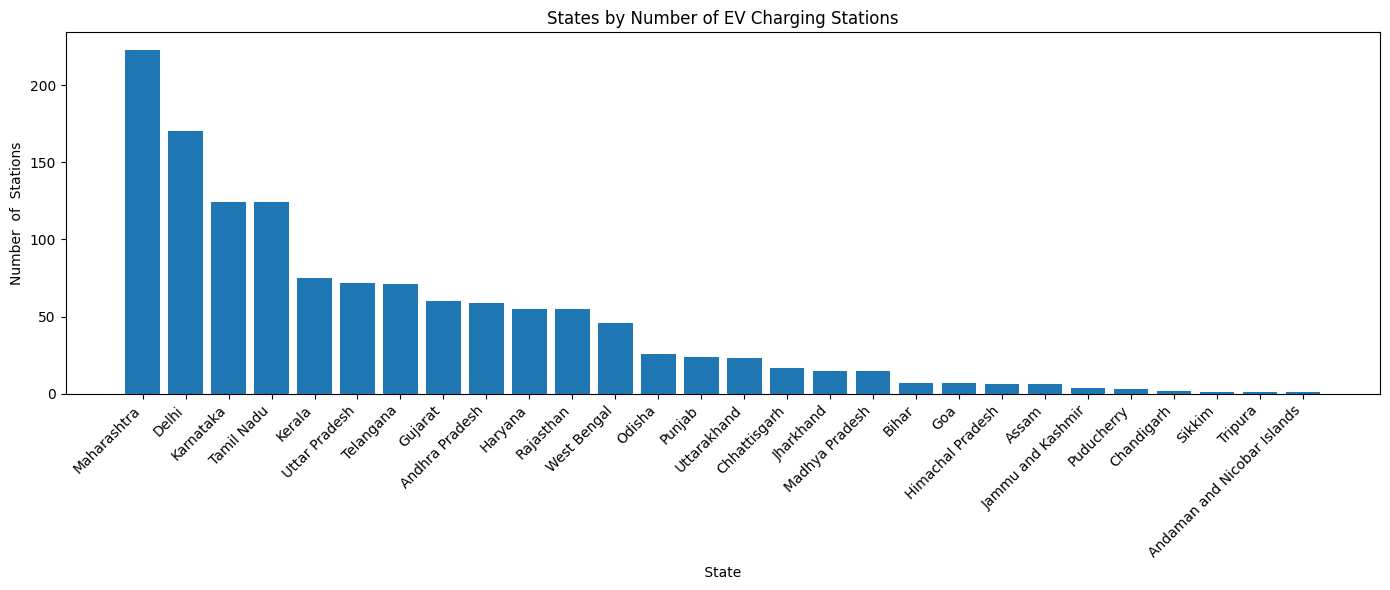

In [363]:
plt.figure(figsize=(14,6))
plt.bar(station_per_state['state'], station_per_state['station_count'])
plt.title('States by Number of EV Charging Stations')
plt.xlabel(' State ')
plt.ylabel('Number  of  Stations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../images/states_ev_count.png', dpi=150, bbox_inches='tight')
plt.show()

- Maharashtra leads with ~220 stations, followed by Delhi at ~170 and Karnataka, Tamil Nadu at ~125 each. 

- States like Tripura, Sikkim, and Andaman & Nicobar Islands have barely any infrastructure. 

- There is a heavy concentration of EV stations in western and southern India, while northern and eastern states are significantly underserved.

Top 15 Cities by EV Station Count

In [364]:
# Count of EV charging stations per city
station_per_city = ev_df['city'].value_counts().reset_index()

station_per_city.columns = ['city', 'station_count']

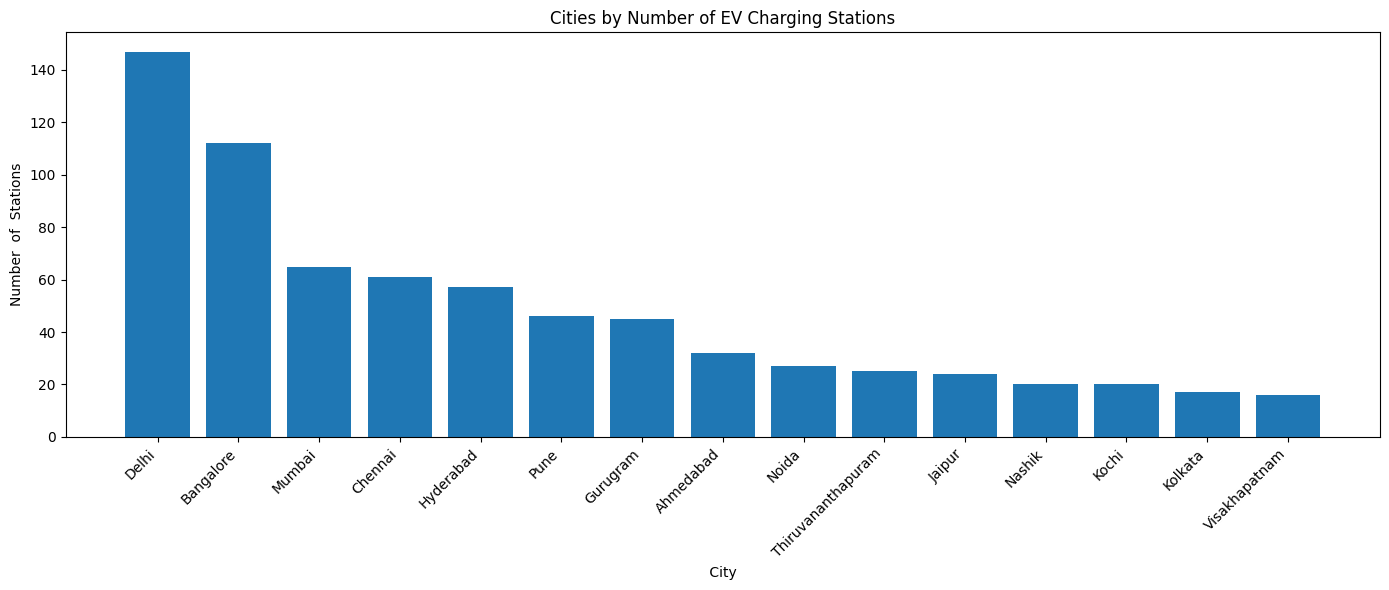

In [365]:
plt.figure(figsize=(14,6))
plt.bar(station_per_city['city'].head(15), station_per_city['station_count'].head(15))
plt.title('Cities by Number of EV Charging Stations')
plt.xlabel(' City ')
plt.ylabel('Number  of  Stations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../images/cities_ev_count.png', dpi=150, bbox_inches='tight')
plt.show()

- Delhi dominates with 147+ stations, followed by Bangalore at ~110 and Mumbai at ~65.

- All top 15 cities are major metros or state capitals

- No tier 2 or tier 3 city appears, suggesting EV infrastructure is almost entirely urban and metro-centric.

Population Distribution Across States

In [366]:
# Sort population dataset by population in descending order
pop_sorted = pop_df.sort_values('population(2024)', ascending=False)

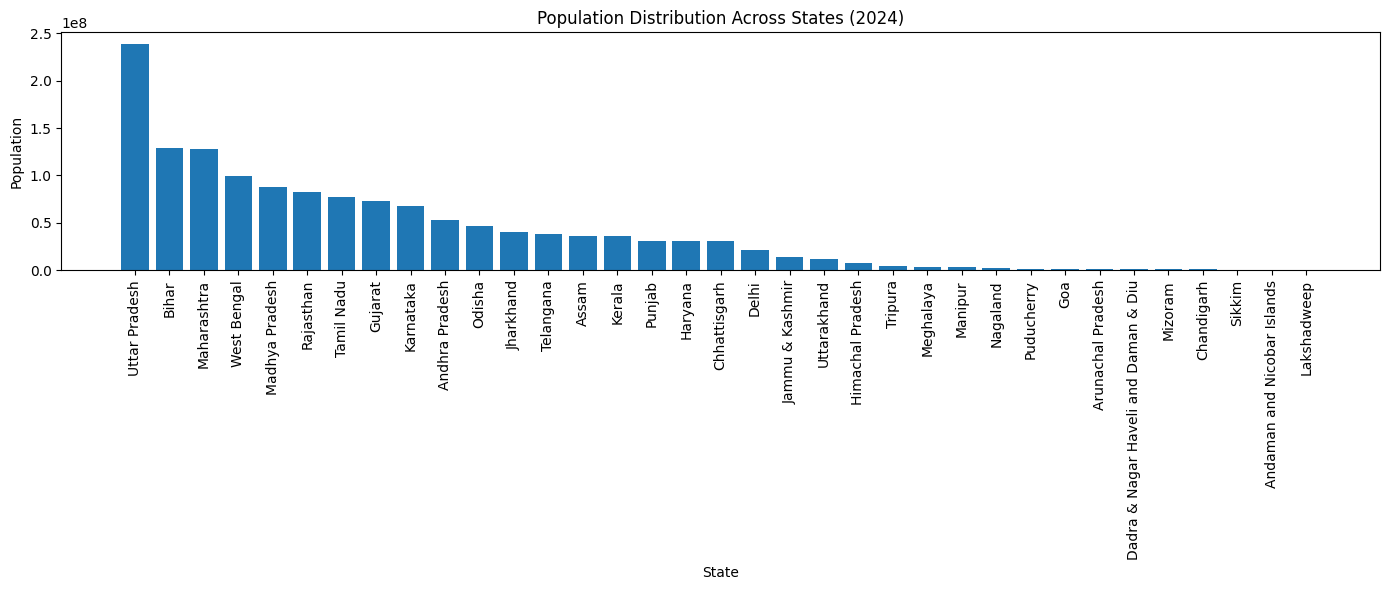

In [367]:
plt.figure(figsize=(14, 6))
plt.bar(pop_sorted['States/Uts'], pop_sorted['population(2024)'])
plt.title('Population Distribution Across States (2024)')
plt.xlabel('State')
plt.ylabel('Population')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../images/population_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

- Uttar Pradesh is by far the most populous state at ~24 crore while Bihar and Maharashtra at ~13 crore each. 

- Small UTs like Lakshadweep, Sikkim, and Andaman & Nicobar Islands have negligible populations. 

- This stark population imbalance will be critical in the gap analysis as high population states with few EV stations are the most underserved.

Note: Y-axis is in scientific notation (1e8 = 10 crore) So 2.5 = 25 crore


Literacy Rate Distribution Across States

In [368]:
# Sort population dataset by literacy rate in descending order
lit_sorted = pop_df.sort_values('average (literacy rate)', ascending=False)

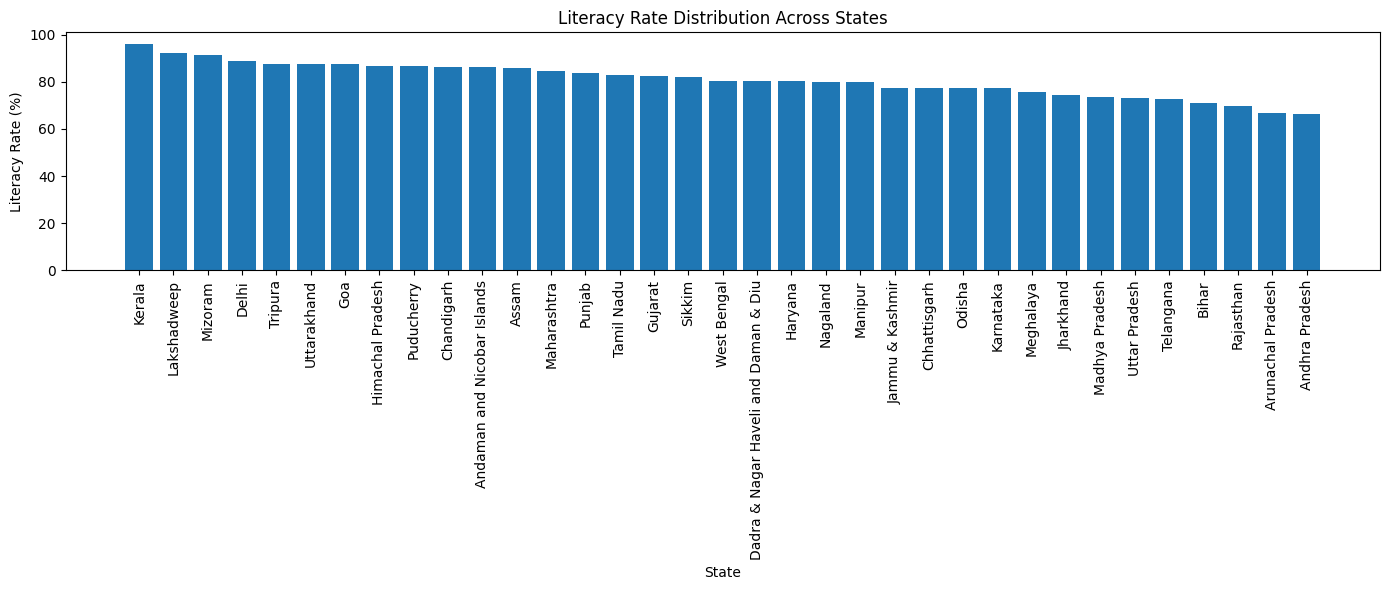

In [369]:
plt.figure(figsize=(14, 6))
plt.bar(lit_sorted['States/Uts'], lit_sorted['average (literacy rate)'])
plt.title('Literacy Rate Distribution Across States')
plt.xlabel('State')
plt.ylabel('Literacy Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../images/literacy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

- Kerala leads with ~96% literacy, followed by Lakshadweep and Mizoram. 

- Andhra Pradesh, Arunachal Pradesh and Rajasthan are at the bottom around ~65%.

- Notably, high literacy states like Kerala and Mizoram don't necessarily have high EV infrastructure, suggesting literacy alone doesn't drive EV adoption.

GDP Distribution Across States

In [370]:
# Sort population dataset by GDP in descending order
gdp_sorted = pop_df.sort_values('GDP', ascending=False)

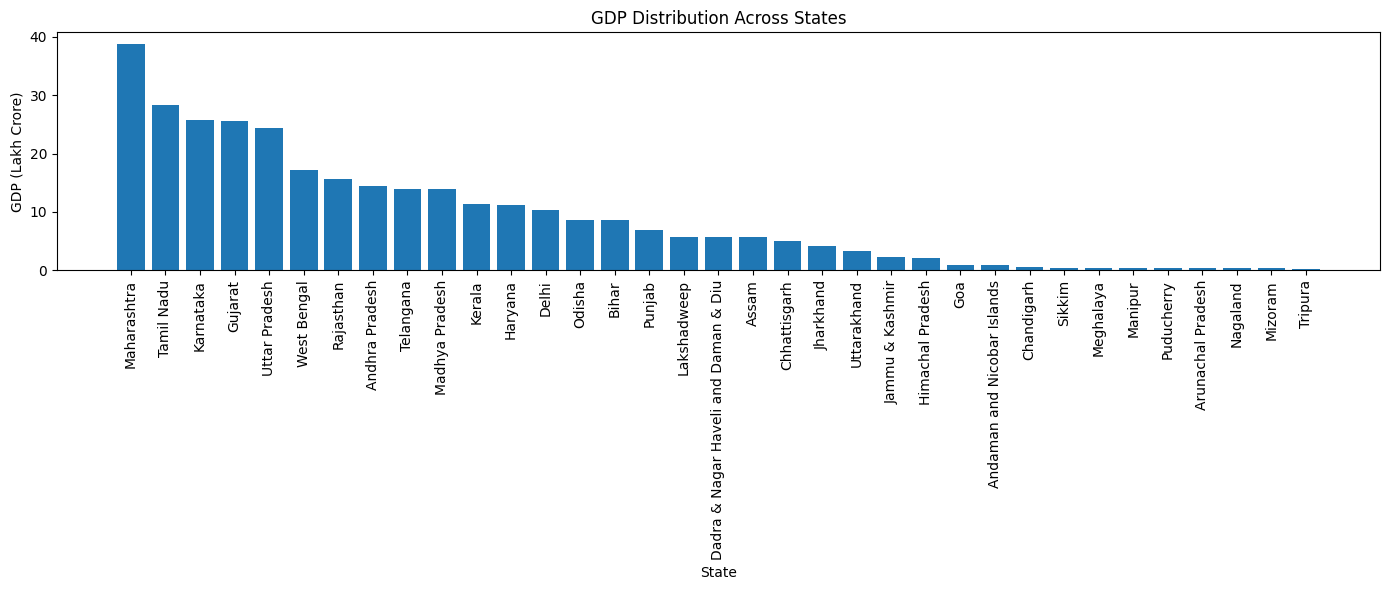

In [371]:
plt.figure(figsize=(14, 6))
plt.bar(gdp_sorted['States/Uts'], gdp_sorted['GDP'])
plt.title('GDP Distribution Across States')
plt.xlabel('State')
plt.ylabel('GDP (Lakh Crore)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../images/gdp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

- Maharashtra dominates with ~39 Lakh Crore GDP, significantly ahead of Tamil Nadu at ~29 Lakh Crore GDP and Karnataka ~26 Lakh Crore GDP. 

- States with high GDP like Maharashtra, Tamil Nadu, Karnataka also appear in the top EV station counts suggesting economic strength drives EV infrastructure investment. 

- Northeastern states and small UTs have negligible GDP and correspondingly very little EV infrastructure.

### Section 4 : Bivariate Analysis

Merge the datasets

In [372]:
# Merge population and station data to analyze bivariate relationships
merged_df = pop_df.merge(station_per_state, left_on='States/Uts', right_on='state', how='left')
merged_df['station_count'] = merged_df['station_count'].fillna(0)

print(merged_df.shape)

merged_df.head()

(35, 8)


,States/Uts,population(2024),Area (sq. km),average (literacy rate),GDP,per capita in,state,station_count
0,Andaman and Nicobar Islands,404000,8249,86.27,0.89,229000.0,Andaman and Nicobar Islands,1.0
1,Andhra Pradesh,53402000,162970,66.40,14.50,219518.0,Andhra Pradesh,59.0
2,Arunachal Pradesh,1580000,83743,66.95,0.38,256410.0,NaN,0.0
3,Assam,36159000,78438,85.90,5.67,118504.0,Assam,6.0
4,Bihar,129205000,94163,70.90,8.59,54000.0,Bihar,7.0


Note: 
- 8 states show 0 EV stations in this dataset. 
- This may not reflect reality — the source dataset is incomplete and likely underrepresents smaller states and UTs. 
- These states will appear as underserved in the gap analysis, but results should be interpreted as indicative trends, not ground truth.

Population vs EV Stations

In [373]:
top_states = merged_df.nlargest(10, 'station_count')['States/Uts'].tolist()

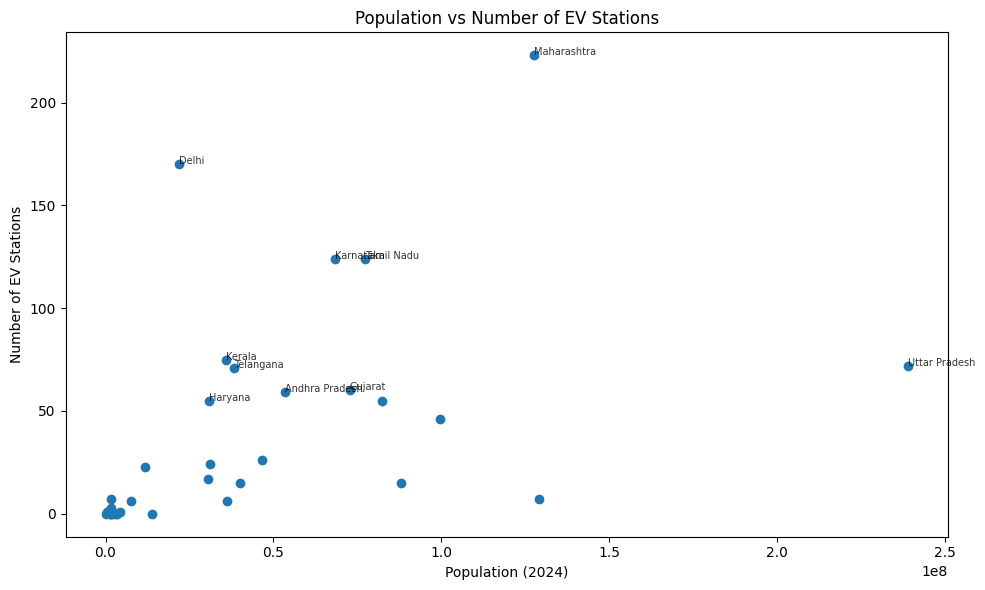

In [374]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['population(2024)'], merged_df['station_count'])
for i, row in merged_df.iterrows():
    if row['States/Uts'] in top_states:
        plt.annotate(row['States/Uts'], (row['population(2024)'], row['station_count']), fontsize=7, alpha=0.8)
plt.title('Population vs Number of EV Stations')
plt.xlabel('Population (2024)')
plt.ylabel('Number of EV Stations')
plt.tight_layout()
plt.savefig('../images/population_vs_stations.png', dpi=150, bbox_inches='tight')
plt.show()

- No clear relationship between population and EV stations 

- Uttar Pradesh with the highest population ~24 crore has only ~70 stations while smaller Delhi has ~170.

GDP vs EV Stations

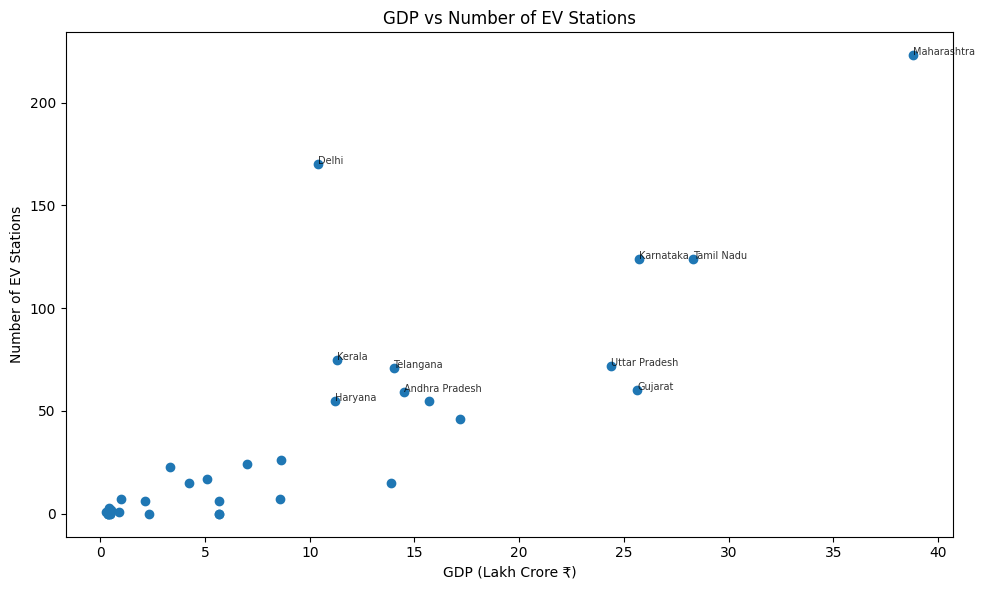

In [375]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['GDP'], merged_df['station_count'])
for i, row in merged_df.iterrows():
    if row['States/Uts'] in top_states:
        plt.annotate(row['States/Uts'], (row['GDP'], row['station_count']), fontsize=7, alpha=0.8)
plt.title('GDP vs Number of EV Stations')
plt.xlabel('GDP (Lakh Crore ₹)')
plt.ylabel('Number of EV Stations')
plt.tight_layout()
plt.savefig('../images/gdp_vs_stations.png', dpi=150, bbox_inches='tight')
plt.show()

- Higher GDP states generally have more EV stations 

- Maharashtra with the highest GDP 39 Lakh Crore also leads with ~220 stations.

Literacy Rate vs EV Stations

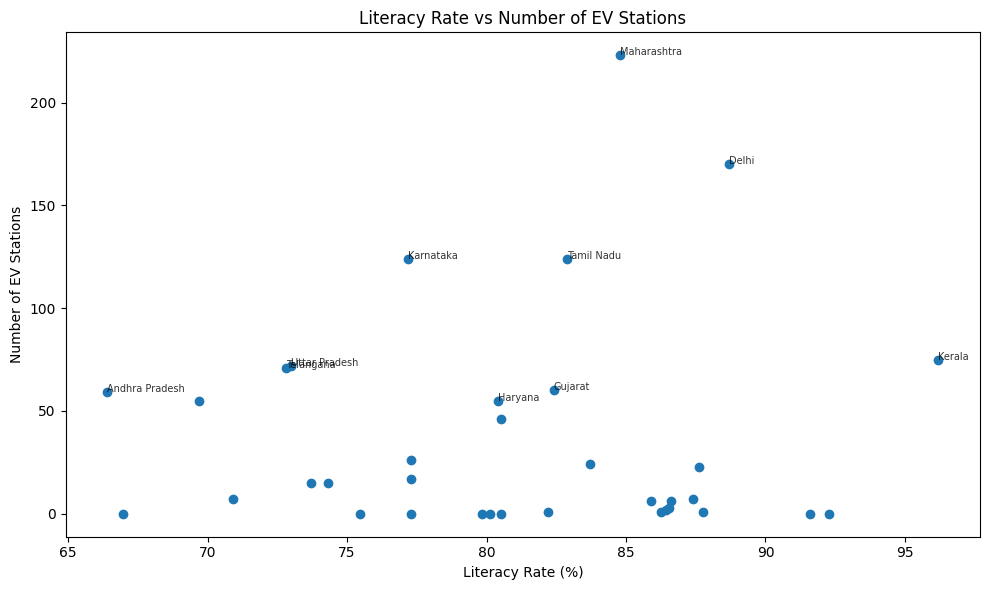

In [376]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['average (literacy rate)'], merged_df['station_count'])
for i, row in merged_df.iterrows():
    if row['States/Uts'] in top_states:
        plt.annotate(row['States/Uts'], (row['average (literacy rate)'], row['station_count']), fontsize=7, alpha=0.8)
plt.title('Literacy Rate vs Number of EV Stations')
plt.xlabel('Literacy Rate (%)')
plt.ylabel('Number of EV Stations')
plt.tight_layout()
plt.savefig('../images/literacy_vs_stations.png', dpi=150, bbox_inches='tight')
plt.show()

- No clear relationship between literacy rate and EV stations 

- Kerala with ~96% literacy has only ~75 stations while states with moderate literacy lead in infrastructure.

Per Capita Income vs Stations per Million

In [377]:
# Calculate stations per million people
merged_df['stations_per_million'] = (merged_df['station_count'] / merged_df['population(2024)']) * 1_000_000

merged_df[['States/Uts', 'stations_per_million']].sort_values('stations_per_million', ascending=False).head()

,States/Uts,stations_per_million
8,Delhi,7.768232
9,Goa,4.416404
0,Andaman and Nicobar Islands,2.475248
16,Kerala,2.085245
33,Uttarakhand,1.949979


In [378]:
top_states_pm = merged_df.nlargest(10, 'stations_per_million')['States/Uts'].tolist()

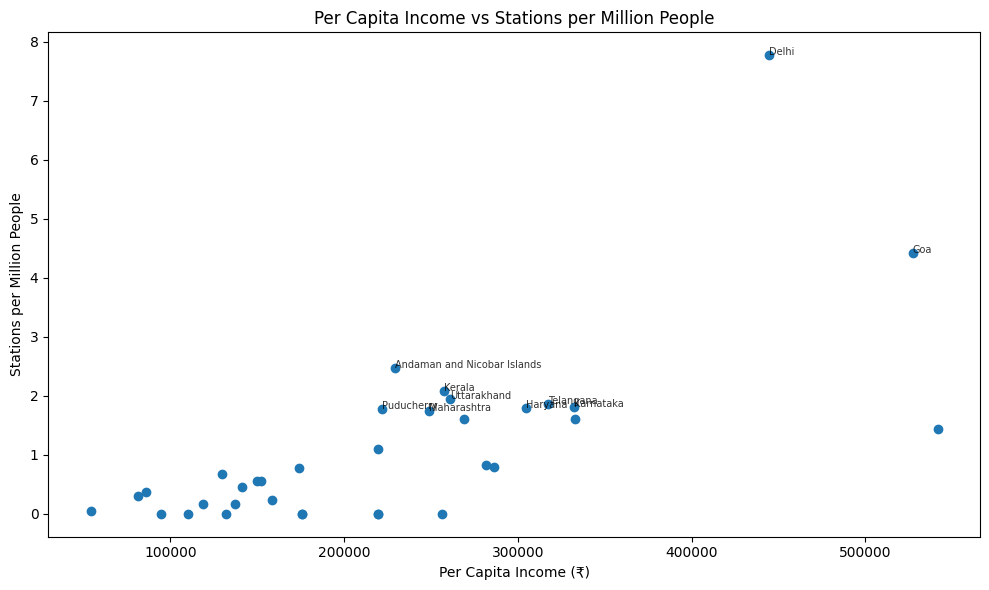

In [379]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['per capita in'], merged_df['stations_per_million'])
for i, row in merged_df.iterrows():
    if row['States/Uts'] in top_states_pm:
        plt.annotate(row['States/Uts'], (row['per capita in'], row['stations_per_million']), fontsize=7, alpha=0.8)
plt.title('Per Capita Income vs Stations per Million People')
plt.xlabel('Per Capita Income (₹)')
plt.ylabel('Stations per Million People')
plt.tight_layout()
plt.savefig('../images/percapita_vs_stations.png', dpi=150, bbox_inches='tight')
plt.show()

- States with higher per capita income tend to have more EV stations per million people, showing a weak positive relationship.

- The outlier at ~4.4 lakh per capita with ~7.8 stations per million is likely Delhi high income and small population combined give it the best EV coverage per person.

- Most low income states cluster near 0, confirming affordability is a key barrier to EV infrastructure development.

Correlation Heatmap

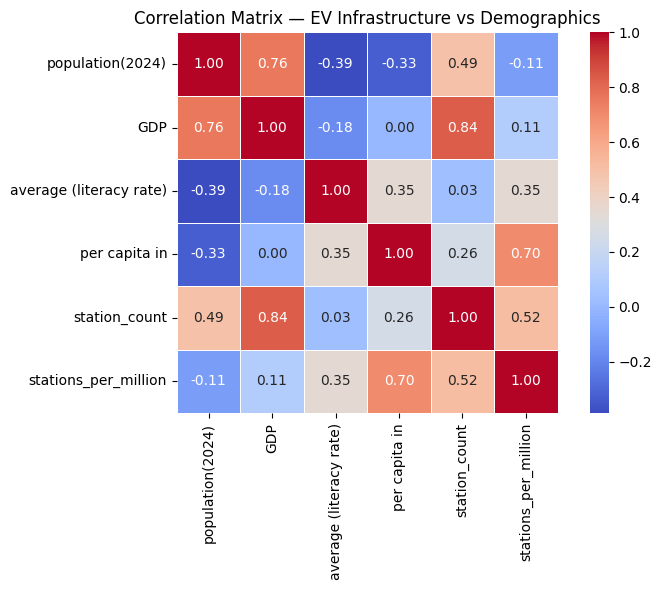

In [380]:
# Correlation matrix of key variables
corr_cols = ['population(2024)', 'GDP', 'average (literacy rate)', 
             'per capita in', 'station_count', 'stations_per_million']

corr_matrix = merged_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — EV Infrastructure vs Demographics')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

- The correlation matrix confirms what individual scatter plots suggested — GDP (0.84) is by far the strongest predictor of EV station count, followed by per capita income (0.70 with stations per million).
 
- Literacy rate shows almost no correlation (0.03), confirming it has no meaningful relationship with EV infrastructure development.

### Section 5 - Gap Analysis

Stations per Million by State

In [381]:
# Create gap dataframe with relevant columns
gap_df = merged_df[['States/Uts', 'population(2024)', 'station_count', 'stations_per_million']].sort_values('stations_per_million', ascending=False)
gap_df.head()

,States/Uts,population(2024),station_count,stations_per_million
8,Delhi,21884000,170.0,7.768232
9,Goa,1585000,7.0,4.416404
0,Andaman and Nicobar Islands,404000,1.0,2.475248
16,Kerala,35967000,75.0,2.085245
33,Uttarakhand,11795000,23.0,1.949979


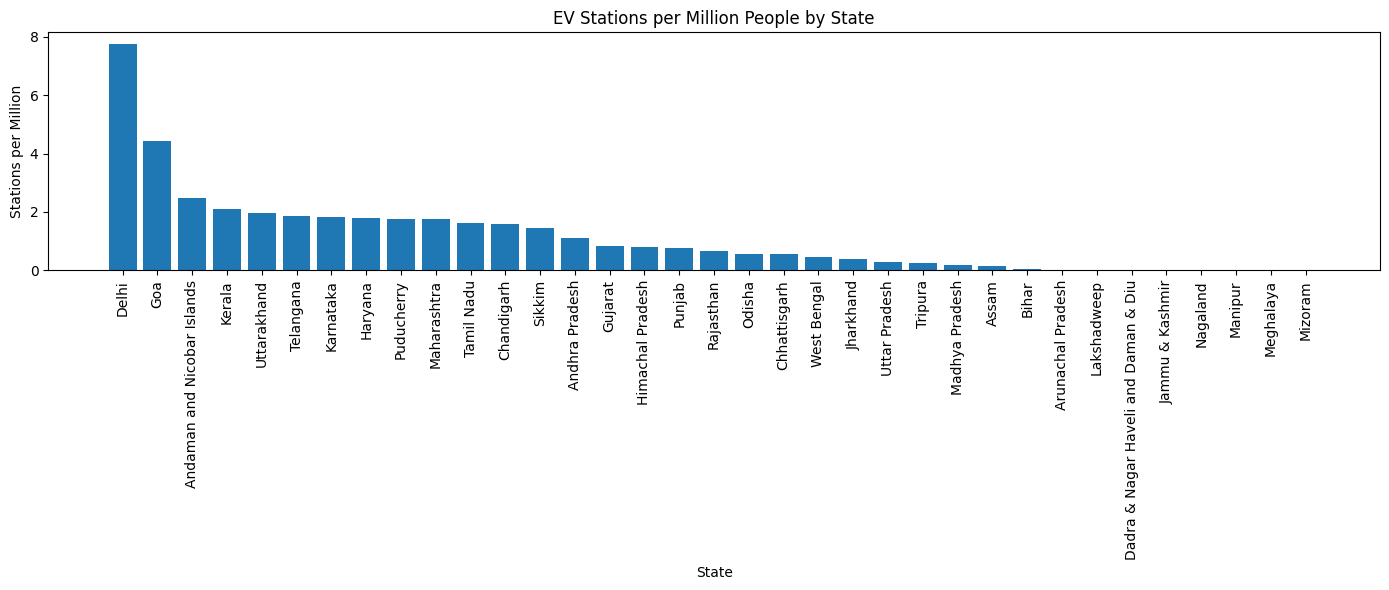

In [382]:
plt.figure(figsize=(14, 6))
plt.bar(gap_df['States/Uts'], gap_df['stations_per_million'])
plt.title('EV Stations per Million People by State')
plt.xlabel('State')
plt.ylabel('Stations per Million')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../images/stations_per_million.png', dpi=150, bbox_inches='tight')
plt.show()

- Delhi leads with ~7.8 stations per million, followed by Goa ~4.5 both small, wealthy, urban territories.

- Large populous states like Bihar, Uttar Pradesh, and Madhya Pradesh are near 0, meaning hundreds of millions of people have virtually no EV access.

- Several northeastern states show 0, likely a data gap but also reflects real infrastructure neglect.

Overserved vs Underserved States

In [383]:
# Top 5 overserved states (high stations per million)
overserved = gap_df.head(5)

print("Overserved States:")
overserved[['States/Uts', 'population(2024)', 'station_count', 'stations_per_million']]


Overserved States:


,States/Uts,population(2024),station_count,stations_per_million
8,Delhi,21884000,170.0,7.768232
9,Goa,1585000,7.0,4.416404
0,Andaman and Nicobar Islands,404000,1.0,2.475248
16,Kerala,35967000,75.0,2.085245
33,Uttarakhand,11795000,23.0,1.949979


In [384]:
# Bottom 5 underserved states (low stations per million)
underserved = gap_df.tail(5)

print("\nUnderserved States:")
underserved[['States/Uts', 'population(2024)', 'station_count', 'stations_per_million']]


Underserved States:


,States/Uts,population(2024),station_count,stations_per_million
13,Jammu & Kashmir,13733000,0.0,0.0
23,Nagaland,2258000,0.0,0.0
20,Manipur,3260000,0.0,0.0
21,Meghalaya,3387000,0.0,0.0
22,Mizoram,1252000,0.0,0.0


Note: 0 stations may reflect data gaps in the source dataset, not necessarily complete absence of infrastructure.

Gap Score

In [385]:
# Calculate gap score: high population and low stations per million = high gap
merged_df['gap_score'] = merged_df['population(2024)'] / (merged_df['stations_per_million'] + 1)

gap_score_df = merged_df[['States/Uts', 'population(2024)', 'stations_per_million', 'gap_score']].sort_values('gap_score', ascending=False)

gap_score_df.head(10)

,States/Uts,population(2024),stations_per_million,gap_score
32,Uttar Pradesh,238875000,0.301413,1.835505e+08
4,Bihar,129205000,0.054177,1.225648e+08
18,Madhya Pradesh,87954000,0.170544,7.513944e+07
34,West Bengal,99723000,0.461278,6.824370e+07
27,Rajasthan,82188000,0.669197,4.923803e+07
19,Maharashtra,127684000,1.746499,4.648973e+07
10,Gujarat,72653000,0.825843,3.979147e+07
3,Assam,36159000,0.165934,3.101291e+07
24,Odisha,46663000,0.557187,2.996622e+07
29,Tamil Nadu,77165000,1.606946,2.959977e+07


Visualize the Gap

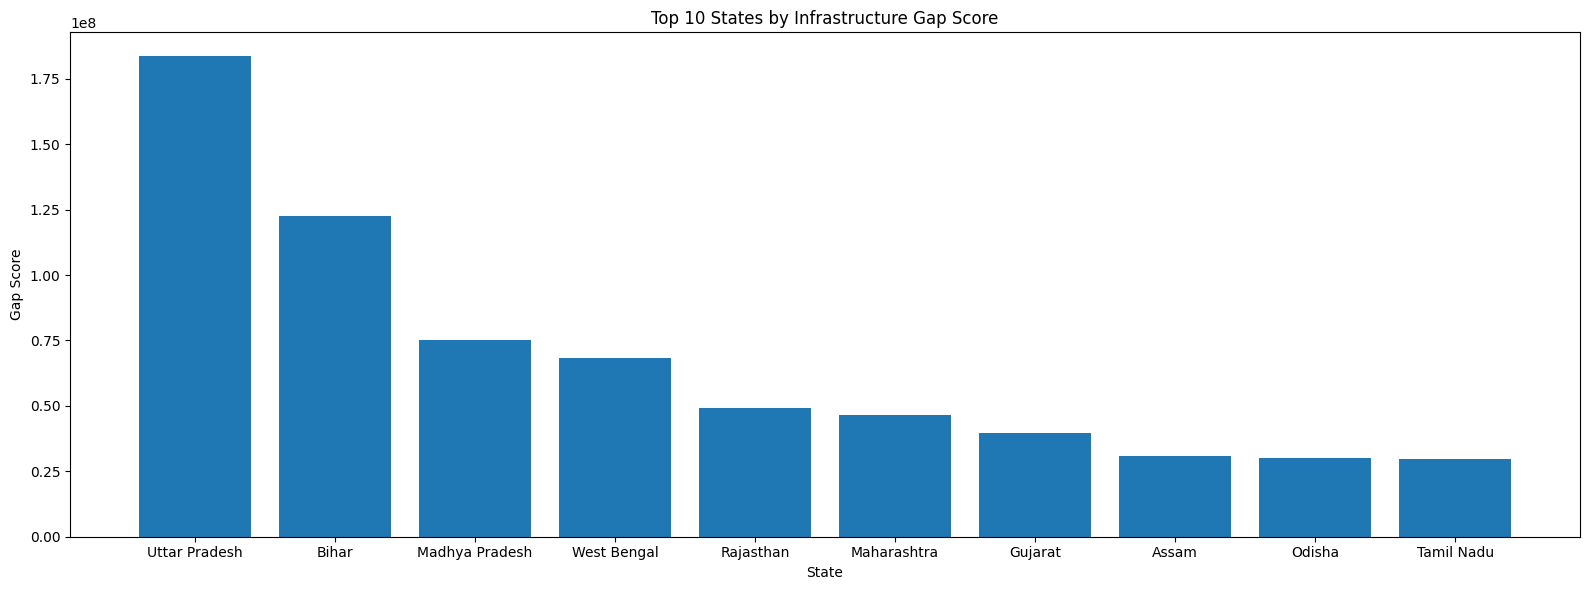

In [386]:
plt.figure(figsize=(16, 6))
plt.bar(gap_score_df['States/Uts'].head(10), gap_score_df['gap_score'].head(10))
plt.title('Top 10 States by Infrastructure Gap Score')
plt.xlabel('State')
plt.ylabel('Gap Score')
plt.tight_layout()
plt.savefig('../images/gap_score.png', dpi=150, bbox_inches='tight')
plt.show()

- Uttar Pradesh has the highest gap score by far ~24 crore people with less than 1 station per million, making it the most infrastructure starved state.

- Bihar and Madhya Pradesh follow together these 3 states represent over 45 crore people with almost no EV coverage.

### Section 6 : Key Findings & Conclusions

- EV infrastructure is heavily metro-centric Delhi, Mumbai, and Bangalore dominate both city and state level counts.

- When adjusted for population, Delhi 7.8 stations/million and Goa 4.4 stations/million lead, while UP and Bihar with 45+ crore people combined have less than 1 station per million.

- GDP turned out to be a stronger predictor of EV infrastructure than population or literacy rate wealthier states invest more, poorer states get left behind.

- Kerala surprised us highest literacy in the country ~96% but only moderate EV infrastructure, showing literacy alone doesn't drive adoption.

- The dataset only covers 1305 stations, which is likely a fraction of ground reality. States showing 0 may simply be missing from the data.

- If there's one takeaway for policymakers — UP, Bihar, and Madhya Pradesh need urgent  attention. The gap between their population and EV coverage is the largest in the country.

### Section 7 : Future Scope

- **EV Sales Data:** Compare state-wise sales vs station count to identify where demand outpaces supply.

- **ML Model:** Predict optimal station locations using population density, GDP, and highway data.

- **Highway Analysis:** Map stations against national highways to expose charging deserts on major routes.

- **Streamlit Dashboard:** Make findings accessible to policymakers through an interactive state-level dashboard.